# 基于子结构的分子生成

本notebook实现基于SELFIES的分子生成，并根据以下条件筛选：
1. 包含指定的子结构
2. 生成的结构相对子结构只能多C和H元素
3. 分子量限制（可配置）
4. 碳链长度限制（可配置）

In [1]:
import time
import selfies
import rdkit
import random
import numpy as np
from rdkit import Chem
from selfies import encoder, decoder
from rdkit.Chem import MolFromSmiles as smi2mol
from rdkit.Chem import AllChem
from rdkit.DataStructs.cDataStructs import TanimotoSimilarity
from rdkit.Chem import Mol
from rdkit.Chem.AtomPairs.Sheridan import GetBPFingerprint, GetBTFingerprint
from rdkit.Chem.Pharm2D import Generate, Gobbi_Pharm2D
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import MolToSmiles as mol2smi
from rdkit import RDLogger
from IPython.display import display
RDLogger.DisableLog('rdApp.*')

## 配置参数
在这里设置您的SMILES、子结构和筛选参数

起始SMILES分子: FP(=O)(C)OC


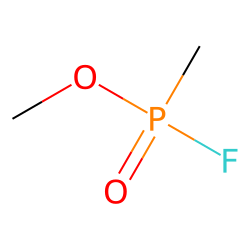


需要保留的子结构: OP(=O)(C)F


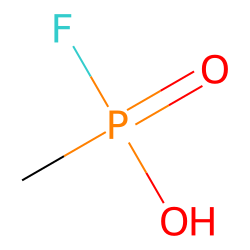

In [ ]:
# ========== 请在这里配置您的参数 ==========

# 起始SMILES分子
starting_smiles = 'FP(=O)(C)O'  # 请替换为您的SMILES

# 需要保留的子结构（SMARTS格式）
required_substructure = 'OP(=O)(C)F'  # 请替换为您的子结构SMILES/SMARTS

# 分子量上限（Da）
max_molecular_weight = 500

# 最长碳链长度（相对于子结构，直接相连的碳原子数）
max_carbon_chain_length = 10

# 生成参数
num_random_samples = 5000  # 随机SMILES样本数（建议500-1000）
# 突变次数列表：每个数字代表对分子进行几次突变
# 突变次数越多，生成的分子与原始分子差异越大，碳链也可能越长
# 这个数组会被遍历，对每个突变次数都生成一批分子
# 例如：[1,2,3]表示分别生成突变1次、2次、3次的分子
# 可以根据需要添加任意数字，如[1,2,3,4,5,10,15,20]
# num_mutation_ls = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15]
num_mutation_ls = [5, 6, 7, 8, 9, 10, 12]
fp_type = 'ECFP4'  # 指纹类型

# ===========================================

# 可视化起始分子和子结构
print("起始SMILES分子:", starting_smiles)
display(Draw.MolToImage(Chem.MolFromSmiles(starting_smiles), size=(250, 250)))
print("\n需要保留的子结构:", required_substructure)
display(Draw.MolToImage(Chem.MolFromSmiles(required_substructure), size=(250, 250)))

## 辅助函数定义

In [3]:
def randomize_smiles(mol):
    '''返回给定分子的随机化（去芳香化）SMILES
    
    Parameters:
    mol (rdkit.Chem.rdchem.Mol): RdKit分子对象
    
    Returns:
    string: 随机化的SMILES字符串
    '''
    if not mol:
        return None
    Chem.Kekulize(mol)
    return rdkit.Chem.MolToSmiles(mol, canonical=False, doRandom=True, 
                                   isomericSmiles=False, kekuleSmiles=True)


def sanitize_smiles(smi):
    '''返回规范化的SMILES表示
    
    Parameters:
    smi (string): 待规范化的SMILES字符串
    
    Returns:
    tuple: (mol对象, 规范化SMILES, 转换是否成功)
    '''
    try:
        mol = smi2mol(smi, sanitize=True)
        smi_canon = mol2smi(mol, isomericSmiles=False, canonical=True)
        return (mol, smi_canon, True)
    except:
        return (None, None, False)


def get_selfie_chars(selfie):
    '''获取SELFIE字符串中的所有字符列表
    
    Parameters:
    selfie (string): SELFIE字符串
    
    Returns:
    list: SELFIE字符列表
    '''
    chars_selfie = []
    while selfie != '':
        chars_selfie.append(selfie[selfie.find('['):selfie.find(']')+1])
        selfie = selfie[selfie.find(']')+1:]
    return chars_selfie

## 筛选函数定义

In [5]:
def get_atom_counts(mol):
    '''获取分子中各元素的原子计数
    
    Parameters:
    mol (rdkit.Chem.rdchem.Mol): RdKit分子对象
    
    Returns:
    dict: 元素符号到计数的字典
    '''
    atom_counts = {}
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        atom_counts[symbol] = atom_counts.get(symbol, 0) + 1
    return atom_counts


def check_only_ch_added(mol_generated, mol_substructure):
    '''检查生成的分子相对于子结构是否只增加了C和H原子
    
    Parameters:
    mol_generated (rdkit.Chem.rdchem.Mol): 生成的分子
    mol_substructure (rdkit.Chem.rdchem.Mol): 子结构分子
    
    Returns:
    bool: True表示只增加了C和H，False表示增加了其他元素
    '''
    counts_gen = get_atom_counts(mol_generated)
    counts_sub = get_atom_counts(mol_substructure)
    
    # 检查是否有新增的非C/H元素
    for element in counts_gen:
        if element not in ['C', 'H']:
            # 如果这个元素在子结构中不存在，或者数量增加了，则违规
            if element not in counts_sub or counts_gen[element] > counts_sub[element]:
                return False
    
    return True


def get_longest_carbon_chain(mol):
    '''获取分子中最长的碳链长度（直接相连的碳原子数）
    
    Parameters:
    mol (rdkit.Chem.rdchem.Mol): RdKit分子对象
    
    Returns:
    int: 最长碳链的长度
    '''
    def dfs(atom, visited, length):
        visited.add(atom.GetIdx())
        max_length = length
        
        for neighbor in atom.GetNeighbors():
            if neighbor.GetSymbol() == 'C' and neighbor.GetIdx() not in visited:
                current_length = dfs(neighbor, visited.copy(), length + 1)
                max_length = max(max_length, current_length)
        
        return max_length
    
    max_chain = 0
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'C':
            chain_length = dfs(atom, set(), 1)
            max_chain = max(max_chain, chain_length)
    
    return max_chain


def check_new_rings_formed(mol_generated, mol_substructure):
    '''检查生成的分子相对于子结构是否形成了新的环
    
    排除逻辑：比较环数量，如果生成分子的环数量多于子结构，说明形成了新环
    
    Parameters:
    mol_generated (rdkit.Chem.rdchem.Mol): 生成的分子
    mol_substructure (rdkit.Chem.rdchem.Mol): 子结构分子
    
    Returns:
    bool: True表示形成了新环，False表示没有形成新环
    '''
    rings_generated = mol_generated.GetRingInfo()
    rings_substructure = mol_substructure.GetRingInfo()
    
    num_rings_generated = rings_generated.NumRings()
    num_rings_substructure = rings_substructure.NumRings()
    
    if num_rings_generated > num_rings_substructure:
        return True
    
    return False


def passes_all_filters(mol, substructure_mol, substructure_smarts, max_mw, max_chain):
    '''检查分子是否通过所有筛选条件
    
    Parameters:
    mol (rdkit.Chem.rdchem.Mol): 待检查的分子
    substructure_mol (rdkit.Chem.rdchem.Mol): 子结构分子对象
    substructure_smarts (string): 子结构SMARTS字符串
    max_mw (float): 最大分子量
    max_chain (int): 最大碳链长度
    
    Returns:
    bool: True表示通过所有筛选，False表示未通过
    '''
    if mol is None:
        return False
    
    # 检查1: 包含子结构
    substructure_pattern = Chem.MolFromSmarts(substructure_smarts)
    if not mol.HasSubstructMatch(substructure_pattern):
        return False
    
    # # 检查2: 只增加了C和H元素
    # if not check_only_ch_added(mol, substructure_mol):
    #     return False
    
    # 检查3: 分子量限制
    mw = Descriptors.MolWt(mol)
    if mw >= max_mw:
        return False
    
    # # 检查4: 碳链长度限制
    # longest_chain = get_longest_carbon_chain(mol)
    # if longest_chain > max_chain:
    #     return False
    
    # # 检查5: 不包含离子（检查是否有带电荷的原子）
    # for atom in mol.GetAtoms():
    #     if atom.GetFormalCharge() != 0:
    #         return False
    
    # # 检查6: 不形成新环
    # if check_new_rings_formed(mol, substructure_mol):
    #     return False

    return True

## SELFIES突变函数

In [6]:
def mutate_selfie(selfie, max_molecules_len, substructure_mol, substructure_smarts, 
                  max_mw, max_chain, write_fail_cases=False):
    '''对SELFIE字符串进行突变（只执行一次突变）
    
    突变会持续进行直到获得有效分子
    突变规则：以33.3%的概率执行以下操作之一：
        1. 在字符串中随机位置添加一个SELFIE字符
        2. 用另一个字符替换随机SELFIE字符
        3. 删除一个随机字符
    
    Parameters:
    selfie (string): 待突变的SELFIE字符串
    max_molecules_len (int): SELFIE字符串突变的最大长度
    substructure_mol (rdkit.Chem.rdchem.Mol): 子结构分子对象
    substructure_smarts (string): 子结构SMARTS字符串
    max_mw (float): 最大分子量
    max_chain (int): 最大碳链长度
    write_fail_cases (bool): 是否记录失败案例
    
    Returns:
    tuple: (突变后的SELFIE字符串, 规范化SMILES)
    '''
    valid = False
    fail_counter = 0
    chars_selfie = get_selfie_chars(selfie)
    
    while not valid:
        fail_counter += 1
        
        # alphabet = list(selfies.get_semantic_robust_alphabet())
        alphabet = [
            '[C]',                   # 30% - 直链碳
            '[C]',
            '[C]',
            '[Branch1][C]',          # 20% - 甲基支链
            '[Branch1][C]',
            '[Branch2][C][C]',       # 10% - 乙基支链
            '[Ring1]',               # 15% - 形成3-6元环
            '[Ring1]',
            '[Ring1]',
            '[Branch1][Ring1]',      # 10% - 带环的支链
            '[C][C][C][C][C][Ring1]',  # 5% - 环己基模式
            '[C][C][C][Ring1]',      # 5% - 环丁基模式
            '[C][C][C][C][Ring1]',
        ]
        choice_ls = [1, 2, 3]  # 1=插入; 2=替换; 3=删除
        random_choice = np.random.choice(choice_ls, 1)[0]
        
        # 在随机位置插入字符
        if random_choice == 1:
            random_index = np.random.randint(len(chars_selfie)+1)
            random_character = np.random.choice(alphabet, size=1)[0]
            selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index:]
        
        # 替换随机字符
        elif random_choice == 2:
            random_index = np.random.randint(len(chars_selfie))
            random_character = np.random.choice(alphabet, size=1)[0]
            if random_index == 0:
                selfie_mutated_chars = [random_character] + chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index+1:]
        
        # 删除随机字符
        elif random_choice == 3:
            random_index = np.random.randint(len(chars_selfie))
            if random_index == 0:
                selfie_mutated_chars = chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = chars_selfie[:random_index] + chars_selfie[random_index+1:]
        
        else:
            raise Exception('尝试执行无效操作')
        
        selfie_mutated = "".join(x for x in selfie_mutated_chars)
        sf = "".join(x for x in chars_selfie)
        
        try:
            smiles = decoder(selfie_mutated)
            mol, smiles_canon, done = sanitize_smiles(smiles)
            
            # 应用所有筛选条件
            if len(selfie_mutated_chars) > max_molecules_len or smiles_canon == "" or \
               not passes_all_filters(mol, substructure_mol, substructure_smarts, max_mw, max_chain):
                done = False
            
            if done:
                valid = True
            else:
                valid = False
        except:
            valid = False
            if fail_counter > 1 and write_fail_cases:
                with open("selfie_failure_cases.txt", "a+") as f:
                    f.write(f'尝试突变SELFIE: {sf} 以获得: {selfie_mutated}\n')
    
    return (selfie_mutated, smiles_canon)


def get_mutated_SELFIES(selfies_ls, num_mutations, substructure_mol, 
                        substructure_smarts, max_mw, max_chain):
    '''对selfies_ls中的所有SELFIES进行num_mutations次突变
    
    Parameters:
    selfies_ls (list): SELFIES列表
    num_mutations (int): 对每个SELFIES执行的突变次数
    substructure_mol (rdkit.Chem.rdchem.Mol): 子结构分子对象
    substructure_smarts (string): 子结构SMARTS字符串
    max_mw (float): 最大分子量
    max_chain (int): 最大碳链长度
    
    Returns:
    list: 突变后的SELFIES列表
    '''
    for _ in range(num_mutations):
        selfie_ls_mut_ls = []
        for str_ in selfies_ls:
            str_chars = get_selfie_chars(str_)
            max_molecules_len = len(str_chars) + num_mutations
            
            selfie_mutated, _ = mutate_selfie(str_, max_molecules_len, substructure_mol,
                                             substructure_smarts, max_mw, max_chain)
            selfie_ls_mut_ls.append(selfie_mutated)
        
        selfies_ls = selfie_ls_mut_ls.copy()
    
    return selfies_ls

## 指纹计算函数

In [7]:
class _FingerprintCalculator:
    '''计算分子的指纹'''
    
    def get_fingerprint(self, mol: Mol, fp_type: str):
        method_name = 'get_' + fp_type
        method = getattr(self, method_name)
        if method is None:
            raise Exception(f'{fp_type} 不是支持的指纹类型')
        return method(mol)
    
    def get_AP(self, mol: Mol):
        return AllChem.GetAtomPairFingerprint(mol, maxLength=10)
    
    def get_PHCO(self, mol: Mol):
        return Generate.Gen2DFingerprint(mol, Gobbi_Pharm2D.factory)
    
    def get_BPF(self, mol: Mol):
        return GetBPFingerprint(mol)
    
    def get_BTF(self, mol: Mol):
        return GetBTFingerprint(mol)
    
    def get_PATH(self, mol: Mol):
        return AllChem.RDKFingerprint(mol)
    
    def get_ECFP4(self, mol: Mol):
        return AllChem.GetMorganFingerprint(mol, 2)
    
    def get_ECFP6(self, mol: Mol):
        return AllChem.GetMorganFingerprint(mol, 3)
    
    def get_FCFP4(self, mol: Mol):
        return AllChem.GetMorganFingerprint(mol, 2, useFeatures=True)
    
    def get_FCFP6(self, mol: Mol):
        return AllChem.GetMorganFingerprint(mol, 3, useFeatures=True)


def get_fingerprint(mol: Mol, fp_type: str):
    '''获取分子指纹'''
    return _FingerprintCalculator().get_fingerprint(mol=mol, fp_type=fp_type)


def get_fp_scores(smiles_back, target_smi, fp_type):
    '''计算SMILES列表与目标结构的Tanimoto指纹相似度
    
    Parameters:
    smiles_back (list): 有效SMILES字符串列表
    target_smi (string): 目标SMILES字符串
    fp_type (string): 指纹类型
    
    Returns:
    list: 指纹相似度列表
    '''
    smiles_back_scores = []
    target = Chem.MolFromSmiles(target_smi)
    fp_target = get_fingerprint(target, fp_type)
    
    for item in smiles_back:
        mol = Chem.MolFromSmiles(item)
        fp_mol = get_fingerprint(mol, fp_type)
        score = TanimotoSimilarity(fp_mol, fp_target)
        smiles_back_scores.append(score)
    
    return smiles_back_scores

## 主要生成流程

In [8]:
# 验证起始分子
mol = Chem.MolFromSmiles(starting_smiles)
if mol is None:
    raise Exception('无效的起始结构')

# 验证子结构
substructure_mol = Chem.MolFromSmiles(required_substructure)
if substructure_mol is None:
    raise Exception('无效的子结构')

print(f"起始SMILES: {starting_smiles}")
print(f"子结构: {required_substructure}")
print(f"分子量上限: {max_molecular_weight} Da")
print(f"碳链长度上限: {max_carbon_chain_length}")
print("\n开始生成...")

起始SMILES: OP(=O)(C)F
子结构: OP(=O)(C)F
分子量上限: 500 Da
碳链长度上限: 10

开始生成...


In [9]:
total_time = time.time()

# 生成随机化的SMILES
start_time = time.time()
randomized_smile_orderings = [randomize_smiles(mol) for _ in range(num_random_samples)]
selfies_ls = [encoder(x) for x in randomized_smile_orderings]
print(f'随机化分子（转换为SELFIES）耗时: {time.time()-start_time:.2f}秒')

# 执行突变
all_smiles_collect = []
start_time = time.time()

for num_mutations in num_mutation_ls:
    print(f"\n执行 {num_mutations} 次突变...")
    selfies_mut = get_mutated_SELFIES(selfies_ls.copy(), num_mutations, 
                                      substructure_mol, required_substructure,
                                      max_molecular_weight, max_carbon_chain_length)
    smiles_back = [decoder(x) for x in selfies_mut]
    all_smiles_collect.extend(smiles_back)
    print(f"  生成了 {len(smiles_back)} 个分子")

print(f'\n突变生成（转换回SMILES）总耗时: {time.time()-start_time:.2f}秒')

随机化分子（转换为SELFIES）耗时: 0.46秒

执行 5 次突变...
  生成了 5000 个分子

执行 6 次突变...
  生成了 5000 个分子

执行 7 次突变...
  生成了 5000 个分子

执行 8 次突变...
  生成了 5000 个分子

执行 9 次突变...
  生成了 5000 个分子

执行 10 次突变...
  生成了 5000 个分子

执行 12 次突变...
  生成了 5000 个分子

突变生成（转换回SMILES）总耗时: 335.62秒


In [10]:
# 规范化并去重
start_time = time.time()
canon_smi_ls = []

for item in all_smiles_collect:
    mol, smi_canon, did_convert = sanitize_smiles(item)
    if mol is None or smi_canon == '' or not did_convert:
        continue
    canon_smi_ls.append(smi_canon)

canon_smi_ls = list(set(canon_smi_ls))
print(f'获得唯一突变结构耗时: {time.time()-start_time:.2f}秒')
print(f'唯一分子数量: {len(canon_smi_ls)}')

获得唯一突变结构耗时: 2.18秒
唯一分子数量: 4122


In [11]:
# 计算指纹相似度
start_time = time.time()
canon_smi_ls_scores = get_fp_scores(canon_smi_ls, target_smi=starting_smiles, fp_type=fp_type)
print(f'指纹计算耗时: {time.time()-start_time:.2f}秒')
print(f'总耗时: {time.time()-total_time:.2f}秒')

指纹计算耗时: 0.38秒
总耗时: 373.59秒


## 结果分析和可视化

In [12]:
# 按相似度分组
indices_thresh_8 = [i for i, x in enumerate(canon_smi_ls_scores) if x > 0.8]
indices_thresh_6 = [i for i, x in enumerate(canon_smi_ls_scores) if 0.6 < x <= 0.8]
indices_thresh_4 = [i for i, x in enumerate(canon_smi_ls_scores) if 0.4 < x <= 0.6]

mols_8 = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in indices_thresh_8]
mols_6 = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in indices_thresh_6]
mols_4 = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in indices_thresh_4]

print(f"\n结果统计:")
print(f"相似度 > 0.8: {len(mols_8)} 个分子")
print(f"相似度 0.6-0.8: {len(mols_6)} 个分子")
print(f"相似度 0.4-0.6: {len(mols_4)} 个分子")


结果统计:
相似度 > 0.8: 1 个分子
相似度 0.6-0.8: 0 个分子
相似度 0.4-0.6: 10 个分子



相似度 > 0.8 的分子（最多显示20个）:


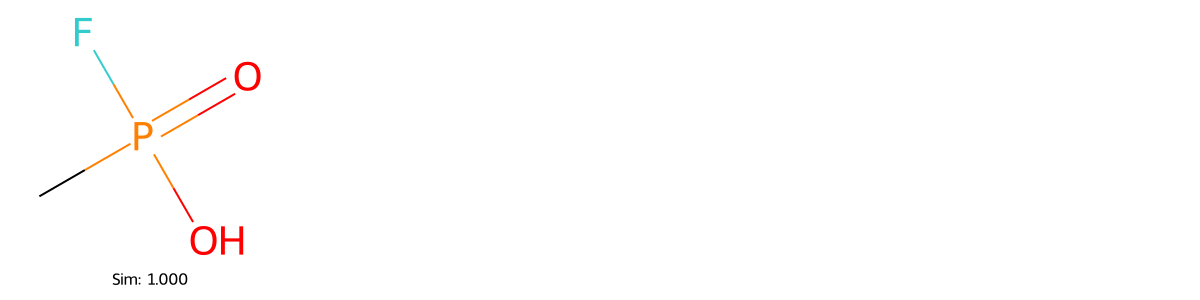

In [12]:
# 显示相似度 > 0.8 的分子（前20个）
if len(mols_8) > 0:
    print("\n相似度 > 0.8 的分子（最多显示20个）:")
    img = Draw.MolsToGridImage(mols_8[:20], molsPerRow=4, subImgSize=(300, 300),
                                legends=[f"Sim: {canon_smi_ls_scores[indices_thresh_8[i]]:.3f}" 
                                        for i in range(min(20, len(mols_8)))])
    display(img)
else:
    print("\n没有找到相似度 > 0.8 的分子")


相似度 0.6-0.8 的分子（最多显示20个）:


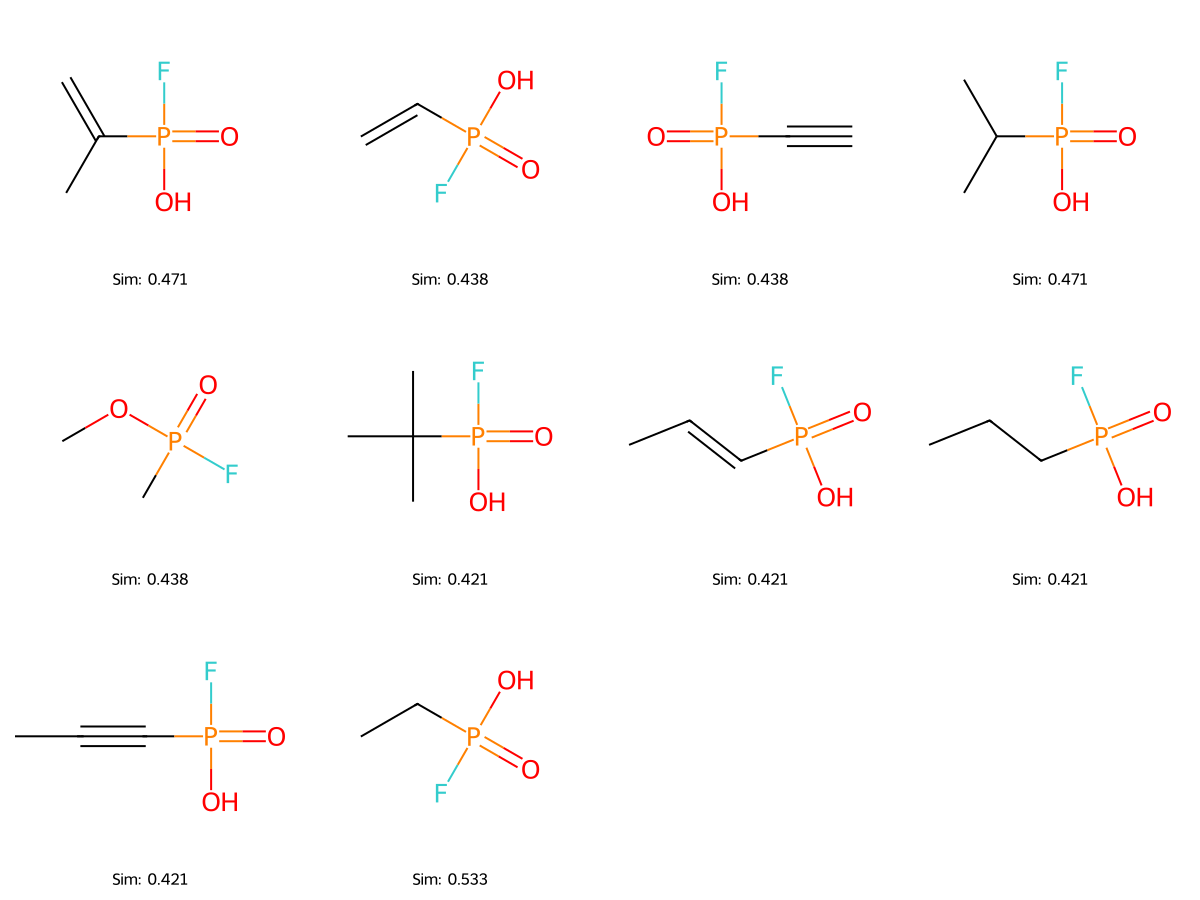

In [13]:
# 显示相似度 0.6-0.8 的分子（前20个）
if len(mols_4) > 0:
    print("\n相似度 0.6-0.8 的分子（最多显示20个）:")
    img = Draw.MolsToGridImage(mols_4[:20], molsPerRow=4, subImgSize=(300, 300),
                                legends=[f"Sim: {canon_smi_ls_scores[indices_thresh_4[i]]:.3f}" 
                                        for i in range(min(20, len(mols_4)))])
    display(img)
else:
    print("\n没有找到相似度 0.6-0.8 的分子")


相似度最低的4个分子:


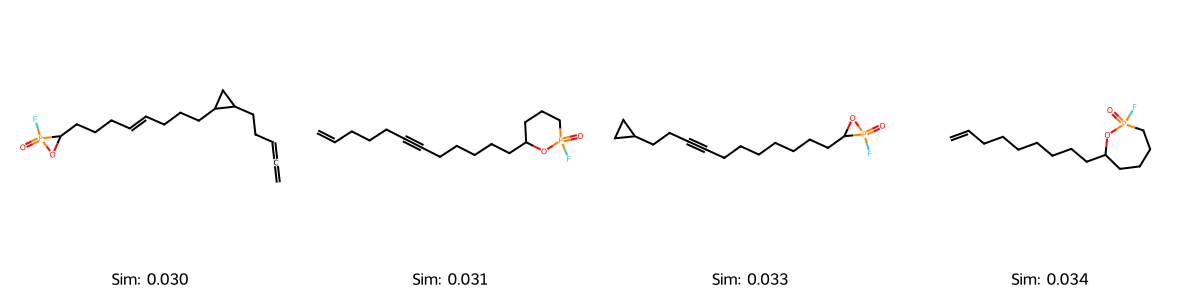

In [14]:
# 显示相似度最低的4个分子
if len(canon_smi_ls) >= 4:
    # 获取相似度最低的4个分子的索引
    sorted_indices = sorted(range(len(canon_smi_ls_scores)), key=lambda i: canon_smi_ls_scores[i])
    lowest_4_indices = sorted_indices[:4]
    lowest_4_mols = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in lowest_4_indices]
    
    print("\n相似度最低的4个分子:")
    img = Draw.MolsToGridImage(lowest_4_mols, molsPerRow=4, subImgSize=(300, 300),
                                legends=[f"Sim: {canon_smi_ls_scores[idx]:.3f}" 
                                        for idx in lowest_4_indices])
    display(img)
elif len(canon_smi_ls) > 0:
    print(f"\n总共只有 {len(canon_smi_ls)} 个分子，显示所有分子:")
    sorted_indices = sorted(range(len(canon_smi_ls_scores)), key=lambda i: canon_smi_ls_scores[i])
    all_mols = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in sorted_indices]
    img = Draw.MolsToGridImage(all_mols, molsPerRow=4, subImgSize=(300, 300),
                                legends=[f"Sim: {canon_smi_ls_scores[idx]:.3f}" 
                                        for idx in sorted_indices])
    display(img)
else:
    print("\n没有生成任何分子")

## 导出结果

In [15]:
import pandas as pd
import os

# 创建输出文件夹
output_dir = 'Highsmi_generate_result'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"创建文件夹: {output_dir}")

# 创建结果DataFrame
results_df = pd.DataFrame({
    'SMILES': canon_smi_ls,
    'Similarity': canon_smi_ls_scores,
    'MolecularWeight': [Descriptors.MolWt(Chem.MolFromSmiles(smi)) for smi in canon_smi_ls],
    'CarbonChainLength': [get_longest_carbon_chain(Chem.MolFromSmiles(smi)) for smi in canon_smi_ls]
})

# 按相似度排序
results_df = results_df.sort_values('Similarity', ascending=False)

# 保存到CSV
output_file = os.path.join(output_dir, 'generated_molecules_with_filters.csv')
results_df.to_csv(output_file, index=False)
print(f"\n结果已保存到: {output_file}")

# 显示前10个结果
print("\n前10个生成的分子:")
display(results_df.head(10))


结果已保存到: Highsmi_generate_result\generated_molecules_with_filters.csv

前10个生成的分子:


,SMILES,Similarity,MolecularWeight,CarbonChainLength
273,CP(=O)(O)F,1.000000,98.013,1
89,CCP(=O)(O)F,0.533333,112.040,2
226,CC(C)P(=O)(O)F,0.470588,126.067,3
199,COP(C)(=O)F,0.437500,112.040,1
180,CC(C)(C)P(=O)(O)F,0.421053,140.094,3
216,CCCP(=O)(O)F,0.421053,126.067,3
126,CCC(C)P(=O)(O)F,0.380952,140.094,4
112,CC(C)CP(=O)(O)F,0.380952,140.094,3
105,CCCCP(=O)(O)F,0.363636,140.094,4
237,CCOP(C)(=O)F,0.350000,126.067,2


In [16]:
# 统计信息
print("\n统计信息:")
print(f"总生成分子数: {len(results_df)}")
print(f"平均相似度: {results_df['Similarity'].mean():.3f}")
print(f"平均分子量: {results_df['MolecularWeight'].mean():.2f} Da")
print(f"平均碳链长度: {results_df['CarbonChainLength'].mean():.2f}")
print(f"\n分子量范围: {results_df['MolecularWeight'].min():.2f} - {results_df['MolecularWeight'].max():.2f} Da")
print(f"碳链长度范围: {results_df['CarbonChainLength'].min():.0f} - {results_df['CarbonChainLength'].max():.0f}")


统计信息:
总生成分子数: 1141
平均相似度: 0.191
平均分子量: 214.65 Da
平均碳链长度: 6.74

分子量范围: 98.01 - 294.39 Da
碳链长度范围: 1 - 14
